/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


starting of generation...


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/controlnet/pipeline_controlnet.py:1053: FutureWarning: `callback` is deprecated and will be removed in version 1.0.0. Passing `callback` as an input argument to `__call__` is deprecated, consider using `callback_on_step_end`
  deprecate(
/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/controlnet/pipeline_controlnet.py:1059: FutureWarning: `callback_steps` is deprecated and will be removed in version 1.0.0. Passing `callback_steps` as an input argument to `__call__` is deprecated, consider using `callback_on_step_end`
  deprecate(


  0%|          | 0/20 [00:00<?, ?it/s]

Step 1. Current value of noise: -0.0041
Step 2. Current value of noise: -0.0081
Step 3. Current value of noise: -0.0166
Step 4. Current value of noise: -0.0177
Step 5. Current value of noise: -0.0269
Step 6. Current value of noise: -0.0329
Step 7. Current value of noise: -0.0405
Step 8. Current value of noise: -0.0495
Step 9. Current value of noise: -0.0569
Step 10. Current value of noise: -0.0665
Step 11. Current value of noise: -0.0735
Step 12. Current value of noise: -0.0819
Step 13. Current value of noise: -0.0886
Step 14. Current value of noise: -0.0954
Step 15. Current value of noise: -0.1012
Step 16. Current value of noise: -0.1063
Step 17. Current value of noise: -0.1106
Step 18. Current value of noise: -0.1141
Step 19. Current value of noise: -0.1170
Step 20. Current value of noise: -0.1170


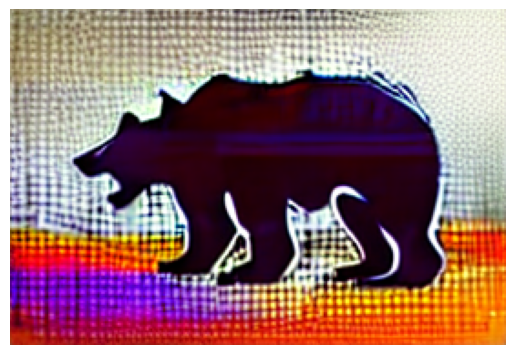

Finished!


In [ ]:
from diffusers import ControlNetModel, StableDiffusionControlNetPipeline
from diffusers.utils import load_image

# ControlNet is an adapter for Stable Diffusion that allows for precise structural control by adding extra conditions like edges, poses, or depth maps.
# While standard Stable Diffusion relies on text prompts, ControlNet forces the model to follow a specific geometry or composition provided by a reference image.

import torch
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import os

# get photo of bear
image_name = "/content/bear.jpg"
base_image = Image.open(image_name).convert("RGB")

# select model
model_id = "runwayml/stable-diffusion-v1-5"

# load pipeline
controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-canny", torch_dtype=torch.float32)

pipe = StableDiffusionControlNetPipeline.from_pretrained(
    model_id, controlnet=controlnet, torch_dtype=torch.float32
).to("cpu")

# use CPU
device = "cpu"
pipe = pipe.to(device)

# our prompt for CLIP
prompt = "A silhouette of a bear made of bright flowers, texture of tulips and roses,  hyperrealistic, 4k"

# function-callback which call in each step of scheduler
def latents_callback(step, timestamp, latents):
  print(f"Step {step}. Current value of noise: {latents.mean().item():.4f}")

# generation
print("starting of generation...")

generator = torch.Generator("cpu").manual_seed(27)

result_image = pipe(
    prompt=prompt,
    image=base_image,
    generator=generator,
    num_inference_steps=20, # num_inference_steps - scheduler for U-Net
    guidance_scale=7.5,
    controlnet_conditioning_scale=0.9, # control of base_image
    callback=latents_callback,
    callback_steps=1 # call 'latents_callback' each step
).images[0]

# save image
result_image.save("polar_bear.png")

plt.imshow(result_image)
plt.axis("off")
plt.show()

print("Finished!")